In [ ]:
from sklearn.model_selection import train_test_split

from Pipeline.Algorithm.ArtificialBeeColonyElmCVEnsemble import ArtificialBeeColonyElmCVEnsemble
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Methodology.EvaluationMatrix import EvaluationMatrix
from Pipeline.Global.Plotting import Plotting

In [ ]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test()

In [ ]:
all_train_curves = []
all_val_curves = []
all_test_scores = []
for idx in range(gallstone_dataset.splits):
    x_train , y_train , x_test , y_test = gallstone_dataset.fold_split[idx]
    x_tr , x_val , y_tr , y_val = train_test_split(x_train, y_train,
                                                test_size= GlobalSetting.test_set_size,
                                                random_state=GlobalSetting.data_split_seed,
                                                stratify=gallstone_dataset.y_train)

    abc_model = ArtificialBeeColonyElmCVEnsemble(
        feature_size        = x_tr.shape[1],
        hidden_size         = GlobalSetting.abc_trace_h_size ,
        activation_function = GlobalSetting.sigmoid,
        regularization_lambda= GlobalSetting.abc_trace_lambda,
        fitness_function    = GlobalSetting.evaluation_function,
        random_state        = GlobalSetting.abc_trace_seed,
        solution_size       = GlobalSetting.abc_trace_s_size,
        trial_limit         = GlobalSetting.abc_trace_t_size,
        max_iteration       = GlobalSetting.abc_trace_m_size
    )
    abc_model.employed_bee_apply_algo3()
    abc_model.onlooker_bee_apply_algo2()
    abc_model.apply_validation_dataset(x_val, y_val)
    abc_model.fit(x_tr, y_tr ,cv_folds= 10)
    val_fitness_curve = abc_model.val_fitness_curve
    best_fitness_curve = abc_model.convergence_curve

    y_pred = abc_model.predict(x_test = x_test)
    evaluation_result = EvaluationMatrix(y_true =y_test, y_pred = y_pred)
    test_score = evaluation_result.get_mcc()
    metric_to_track = GlobalSetting.evaluation_function
    final_test_score = evaluation_result.get_all_metrics()[metric_to_track]

    all_train_curves.append(best_fitness_curve)
    all_val_curves.append(val_fitness_curve)
    all_test_scores.append(test_score)



In [ ]:
Plotting.plot_cv_grid(
    all_train_curves=all_train_curves,
    all_val_curves=all_val_curves,
    all_test_scores=all_test_scores,
    experiment_name=f"ABC-ELM_10F_CV_Ensemble | Test: {gallstone_dataset.splits}-Fold",
    fitness_metric=GlobalSetting.evaluation_function,
    is_final_record=False
)

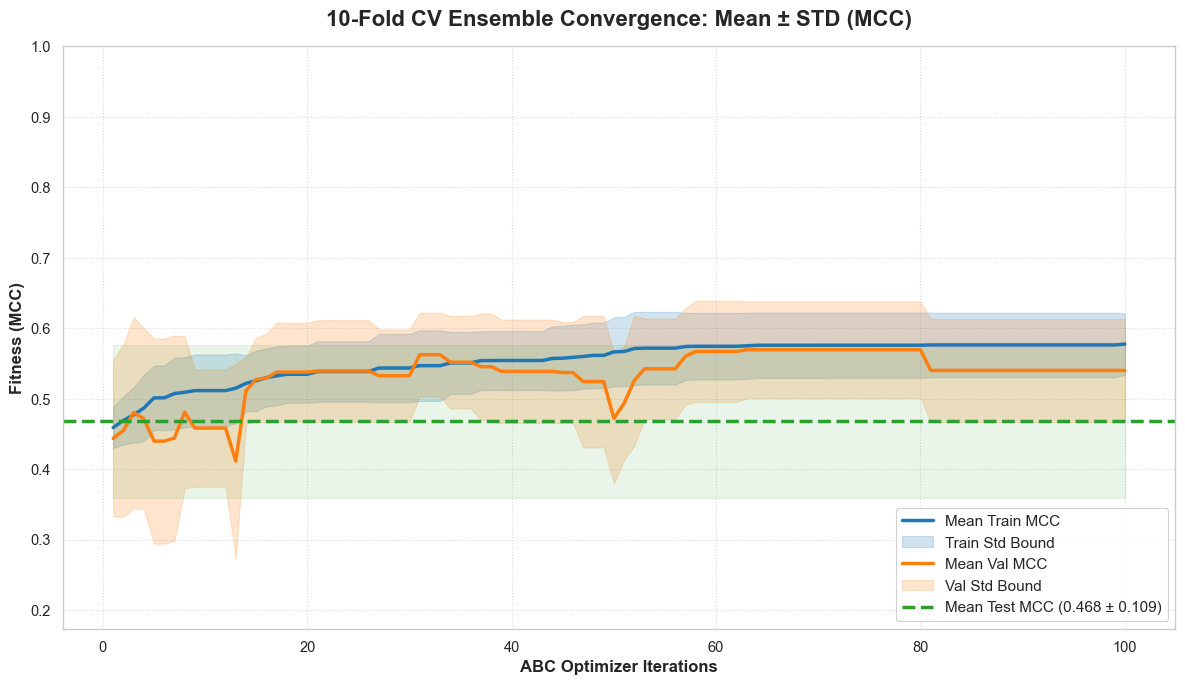

In [4]:
def plot_cv_aggregate_results(all_train_curves, all_val_curves, all_test_scores, metric_name="MCC"):
    """
    Plots the Mean and Standard Deviation bounds for K-Fold Cross-Validation traces.
    """
    # 1. Convert lists to 2D numpy matrices: Shape becomes (K_Folds, Max_Iterations)
    train_matrix = np.array(all_train_curves)
    val_matrix = np.array(all_val_curves)

    # 2. Calculate the Mean and Standard Deviation along the fold axis (axis=0)
    mean_train = np.mean(train_matrix, axis=0)
    std_train  = np.std(train_matrix, axis=0)

    mean_val = np.mean(val_matrix, axis=0)
    std_val  = np.std(val_matrix, axis=0)

    mean_test = np.mean(all_test_scores)
    std_test  = np.std(all_test_scores)

    # Define the X-axis (Iterations)
    iterations = np.arange(1, len(mean_train) + 1)

    # 3. Plotting Execution
    plt.figure(figsize=(12, 7))

    # --- A. Training Plot (Blue) ---
    plt.plot(iterations, mean_train, label=f'Mean Train {metric_name}', color='tab:blue', linewidth=2.5)
    plt.fill_between(iterations,
                     mean_train - std_train,
                     mean_train + std_train,
                     color='tab:blue', alpha=0.2, label='Train Std Bound')

    # --- B. Validation Plot (Orange) ---
    plt.plot(iterations, mean_val, label=f'Mean Val {metric_name}', color='tab:orange', linewidth=2.5)
    plt.fill_between(iterations,
                     mean_val - std_val,
                     mean_val + std_val,
                     color='tab:orange', alpha=0.2, label='Val Std Bound')

    # --- C. Test Baseline Plot (Green Dashed Line) ---
    # Since Test is evaluated once per fold, we represent it as a flat baseline across the iterations
    plt.axhline(y=mean_test, color='tab:green', linestyle='--', linewidth=2.5,
                label=f'Mean Test {metric_name} ({mean_test:.3f} ± {std_test:.3f})')
    plt.fill_between(iterations,
                     mean_test - std_test,
                     mean_test + std_test,
                     color='tab:green', alpha=0.1)

    # --- D. Aesthetics & Labels ---
    plt.title(f'10-Fold CV Ensemble Convergence: Mean ± STD ({metric_name})', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('ABC Optimizer Iterations', fontsize=12, fontweight='bold')
    plt.ylabel(f'Fitness ({metric_name})', fontsize=12, fontweight='bold')

    # Configure Legend and Grid
    plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.7)

    # Set y-limits slightly wider to accommodate variance visually
    plt.ylim(bottom=max(0, np.min(mean_val - std_val) - 0.1), top=1.0)

    plt.tight_layout()
    plt.show()

plot_cv_aggregate_results(all_train_curves, all_val_curves, all_test_scores, metric_name="MCC")